# Downstream Analysis

This notebook should be used for downstream analysis of your OPS screen.
Cells marked with <font color='red'>SET PARAMETERS</font> contain crucial variables that need to be set according to your specific experimental setup and data organization.
Please review and modify these variables as needed before proceeding with the analysis.

## <font color='red'>SET PARAMETERS</font>

### Fixed parameters for cluster module

- `CONFIG_FILE_PATH`: Path to a Brieflow config file used during processing. Absolute or relative to where workflows are run from.

In [1]:
CONFIG_FILE_PATH = "config/config.yml"

In [2]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
import yaml
import pandas as pd
import matplotlib.pyplot as plt

from lib.cluster.cluster_analysis import (
    differential_analysis, 
    waterfall_plot, 
    two_feature_plot, 
    cluster_heatmap,
    volcano_plot,
)
from lib.cluster.cluster_eval import analyze_all_resolutions, merge_bootstrap_with_genes
from lib.cluster.phate_leiden_clustering import plot_phate_leiden_clusters
from lib.shared.metrics import get_all_stats

In [3]:
# load config file and determine root path
with open(CONFIG_FILE_PATH, "r") as config_file:
    config = yaml.safe_load(config_file)
    ROOT_FP = Path(config["all"]["root_fp"])

In [4]:
# Load cell classes and channel combos from config
cluster_combo_fp = config["cluster"]["cluster_combo_fp"]
cluster_combos = pd.read_csv(cluster_combo_fp, sep="\t")

CHANNEL_COMBOS = list(cluster_combos["channel_combo"].unique())
CELL_CLASSES = list(cluster_combos["cell_class"].unique())

print(f"Channel Combos: {CHANNEL_COMBOS}")
print(f"Cell classes: {CELL_CLASSES}")

Channel Combos: ['DAPI_TUBULIN_GH2AX_PHALLOIDIN']
Cell classes: ['Interphase', 'Mitotic', 'all']


## Pipeline Statistics Report

This function analyzes the entire data processing pipeline from raw microscopy images to clustered perturbation profiles. It reports:

1. **Preprocessing**: Input files and generated image tiles
2. **SBS**: Cell segmentation and barcode mapping success rates  
3. **Phenotype**: Cells and morphological features extracted
4. **Merge**: Phenotype/SBS matching rates and single gene mapping
5. **Aggregation**: Perturbation coverage and cell counts per class
6. **Clustering**: Pathway enrichment metrics (CORUM, KEGG, STRING)

To include batch effect metrics (slower), use: `get_all_stats(config, include_batch_effects=True)`. To save this report, set an `output_fp` (`.txt`) file.

In [5]:
statistics = get_all_stats(                                                                                                                                                                                                  
    config,
    include_batch_effects=True,
    sbs_tiff_dirs=["brieflow_output/preprocess/images/sbs", "/archive/cheeseman/ops_analysis/aconcagua-analysis/analysis/brieflow_output/preprocess/images/sbs"],
    phenotype_tiff_dirs=["brieflow_output/preprocess/images/phenotype", "/archive/cheeseman/ops_analysis/aconcagua-analysis/analysis/brieflow_output/preprocess/images/phenotype"],
    output_fp= ROOT_FP / "aconcagua_stats.txt",
)

PIPELINE STATISTICS REPORT

[1/6] Gathering preprocessing statistics...

 PREPROCESSING STATISTICS:
   - ND2 input files: 2,049
   - SBS tiles generated: 168,165
   - Phenotype tiles generated: 58,926

[2/6] Gathering SBS statistics...

 SBS STATISTICS:
   - Total cells segmented: 74,406,684
   - Cells with barcode: 79.2% (58,980,065 cells)
   - Cells with unique gene mapping: 57.0% (42,371,543 cells)

[3/6] Gathering phenotype statistics...

 PHENOTYPE STATISTICS:
   - Total cells segmented: 71,629,095
   - Number of morphological features: 1,651

[4/6] Gathering merge statistics...

 MERGE STATISTICS:
   - Phenotype cells segmented: 71,629,095
   - SBS cells segmented: 74,406,684
   - Total matched cell pairs: 54,683,953
   - Phenotype recovery: 76.4% (54,683,953 unique phenotype cells in merge)
   - SBS recovery: 70.4% (52,411,642 unique SBS cells in merge)
   - Cells with barcode: 36,078,425 (66.0% of matched pairs)
   - Cells with single gene: 31,654,068 (87.7% of cells with barco

## <font color='red'>SET PARAMETERS</font>

### Optimal Resolution Configuration

- `METRIC`: Scoring strategy for ranking resolutions — `"balanced"` (recommended), `"combined"` (enrichment only), or individual metrics (`"corum_enrichment"`, `"kegg_enrichment"`, `"string_f1"`)
- `IDEAL_SIZE_RANGE`: Target mean genes per cluster `(min, max)`. The scorer penalizes resolutions whose mean cluster size falls outside this range, with a steep penalty above the maximum. 
- `SIZE_METRIC`: Whether to use `"mean"` or `"median"` cluster size for scoring

In [6]:
METRIC = "balanced"          # "balanced", "combined", "corum_enrichment", "kegg_enrichment", "string_f1"
IDEAL_SIZE_RANGE = (20, 29)  # Target mean genes per cluster; (20, 29) selects k=12 (Interphase) and k=5 (Mitotic)
SIZE_METRIC = "mean"         # "mean" or "median"


Interphase / DAPI_TUBULIN_GH2AX_PHALLOIDIN
  Optimal resolution: 12
  Optimization metric: balanced
  Size metric used: mean
  Target size range: (20, 29)

Top 10 resolutions (sorted by balanced score):


,Resolution,# Clusters,Median Size,Mean Size,CORUM %,KEGG %,STRING F1 %,# CORUM,Balanced Score,Enrichment Score
0,12,227,18,23.3,33.0,18.1,9.8,75,89.2,81.0
1,15,279,15,19.0,29.4,15.1,10.7,82,86.7,76.8
2,11,209,20,25.4,35.9,16.7,9.3,75,85.9,79.8
3,13,241,17,22.0,30.7,16.6,9.8,74,85.8,77.2
4,14,260,16,20.4,31.9,15.4,10.4,83,84.5,78.2
5,9,172,24,30.8,35.5,19.2,8.4,61,83.8,80.0
6,10,188,21,28.2,35.1,20.2,8.9,66,75.1,83.1
7,8,154,27,34.4,39.0,18.8,8.1,60,72.0,81.2
8,7,135,32,39.3,38.5,19.3,7.6,52,54.5,80.1
9,6,113,41,46.9,45.1,23.0,7.1,51,44.4,88.8


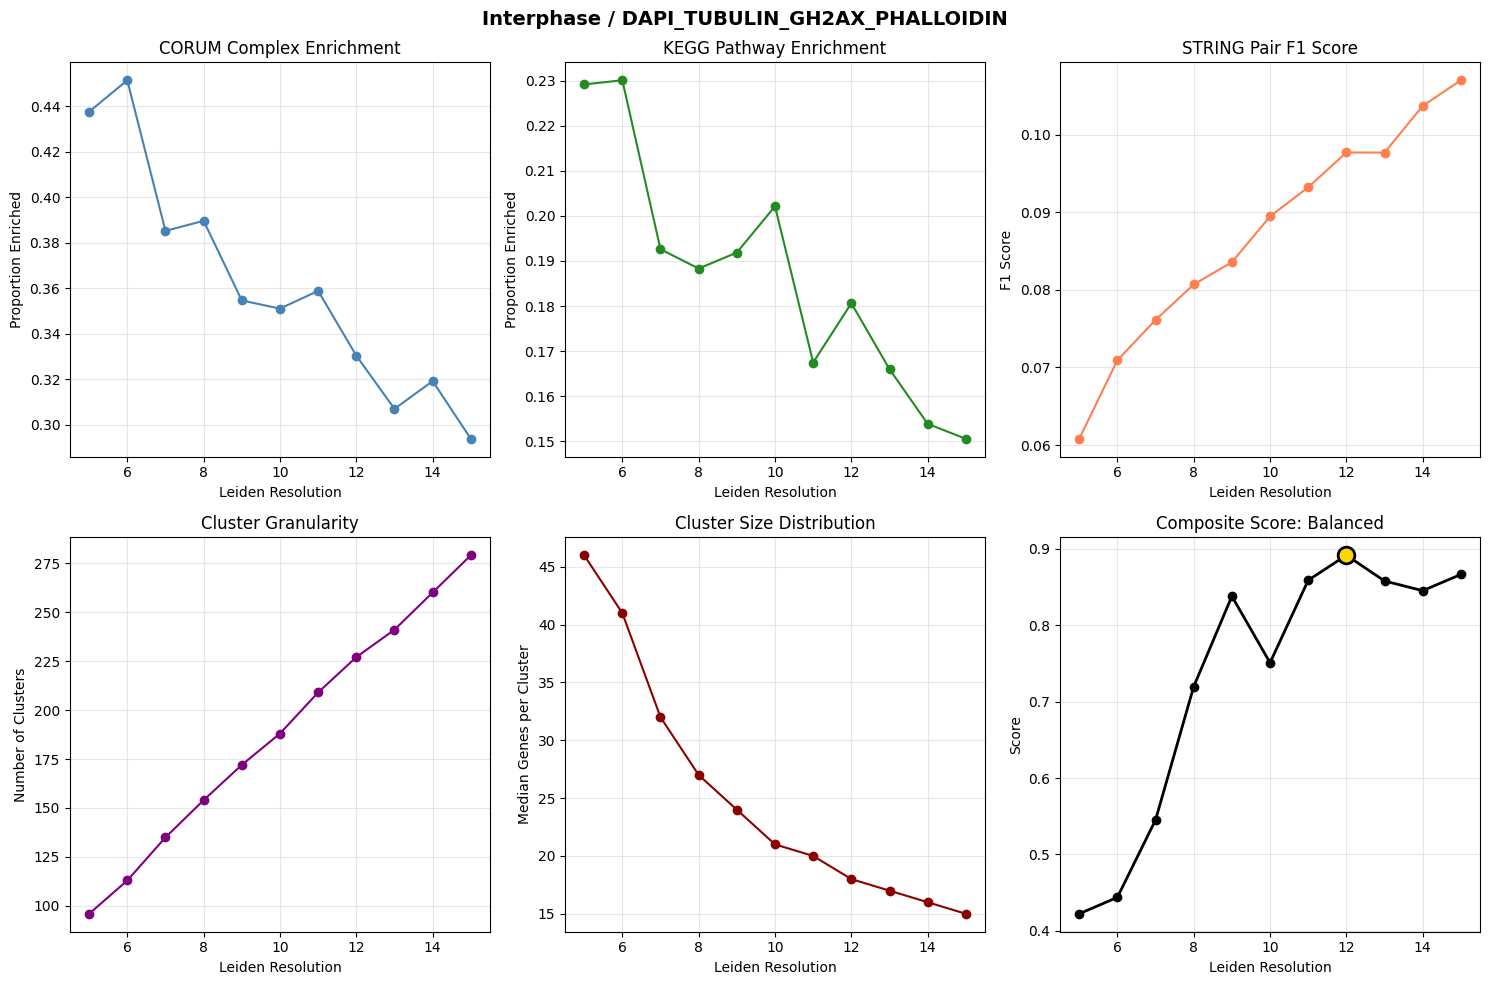


Mitotic / DAPI_TUBULIN_GH2AX_PHALLOIDIN
  Optimal resolution: 5
  Optimization metric: balanced
  Size metric used: mean
  Target size range: (20, 29)

Top 10 resolutions (sorted by balanced score):


,Resolution,# Clusters,Median Size,Mean Size,CORUM %,KEGG %,STRING F1 %,# CORUM,Balanced Score,Enrichment Score
0,5,222,22,23.8,5.4,3.2,6.5,12,93.5,88.6
1,6,260,18,20.4,5.4,3.8,6.8,14,93.5,96.1
2,7,290,16,18.3,4.1,3.1,7.1,12,88.5,83.1
3,8,325,15,16.3,4.9,3.4,7.1,16,88.4,90.2
4,9,351,14,15.1,4.6,2.6,7.2,16,81.8,81.4
5,10,388,12,13.6,3.9,2.6,7.5,15,77.4,78.5
6,11,412,12,12.8,3.9,2.4,7.7,16,75.7,78.3
7,12,443,11,12.0,3.4,2.5,7.5,15,72.4,74.8
8,14,493,10,10.7,3.7,2.2,7.3,18,69.0,73.5
9,13,456,11,11.6,3.1,2.2,7.2,14,68.7,69.1


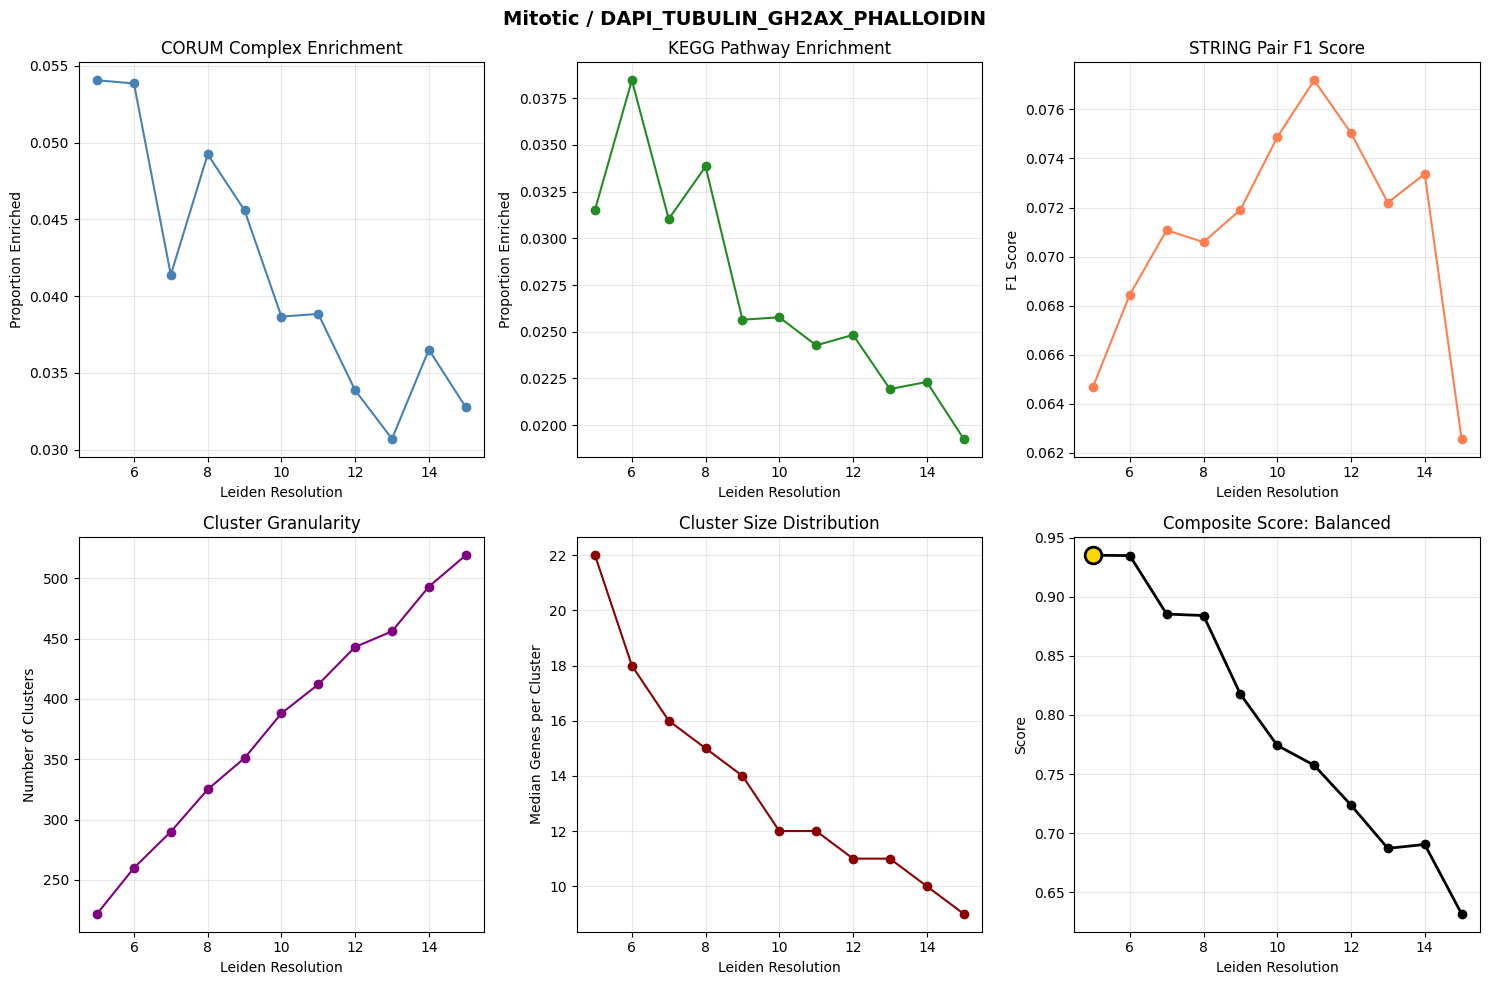


all / DAPI_TUBULIN_GH2AX_PHALLOIDIN
  Optimal resolution: 12
  Optimization metric: balanced
  Size metric used: mean
  Target size range: (20, 29)

Top 10 resolutions (sorted by balanced score):


,Resolution,# Clusters,Median Size,Mean Size,CORUM %,KEGG %,STRING F1 %,# CORUM,Balanced Score,Enrichment Score
0,12,227,18,23.3,30.0,17.2,10.0,68,87.0,76.7
1,11,214,19,24.8,31.3,17.3,9.4,67,86.6,75.8
2,15,271,15,19.6,28.0,14.8,10.6,76,86.2,73.8
3,13,242,17,21.9,30.6,16.1,10.1,74,85.0,75.8
4,14,259,16,20.5,29.7,15.1,9.9,77,82.1,73.2
5,9,172,25,30.8,32.0,18.6,8.3,55,81.1,74.7
6,10,191,22,27.7,30.9,17.3,9.0,59,73.0,74.4
7,8,154,28,34.4,34.4,18.8,7.8,53,69.0,75.3
8,7,132,33,40.1,37.1,18.9,7.4,49,49.8,76.1
9,5,97,49,54.6,47.4,23.7,6.2,46,43.1,86.1


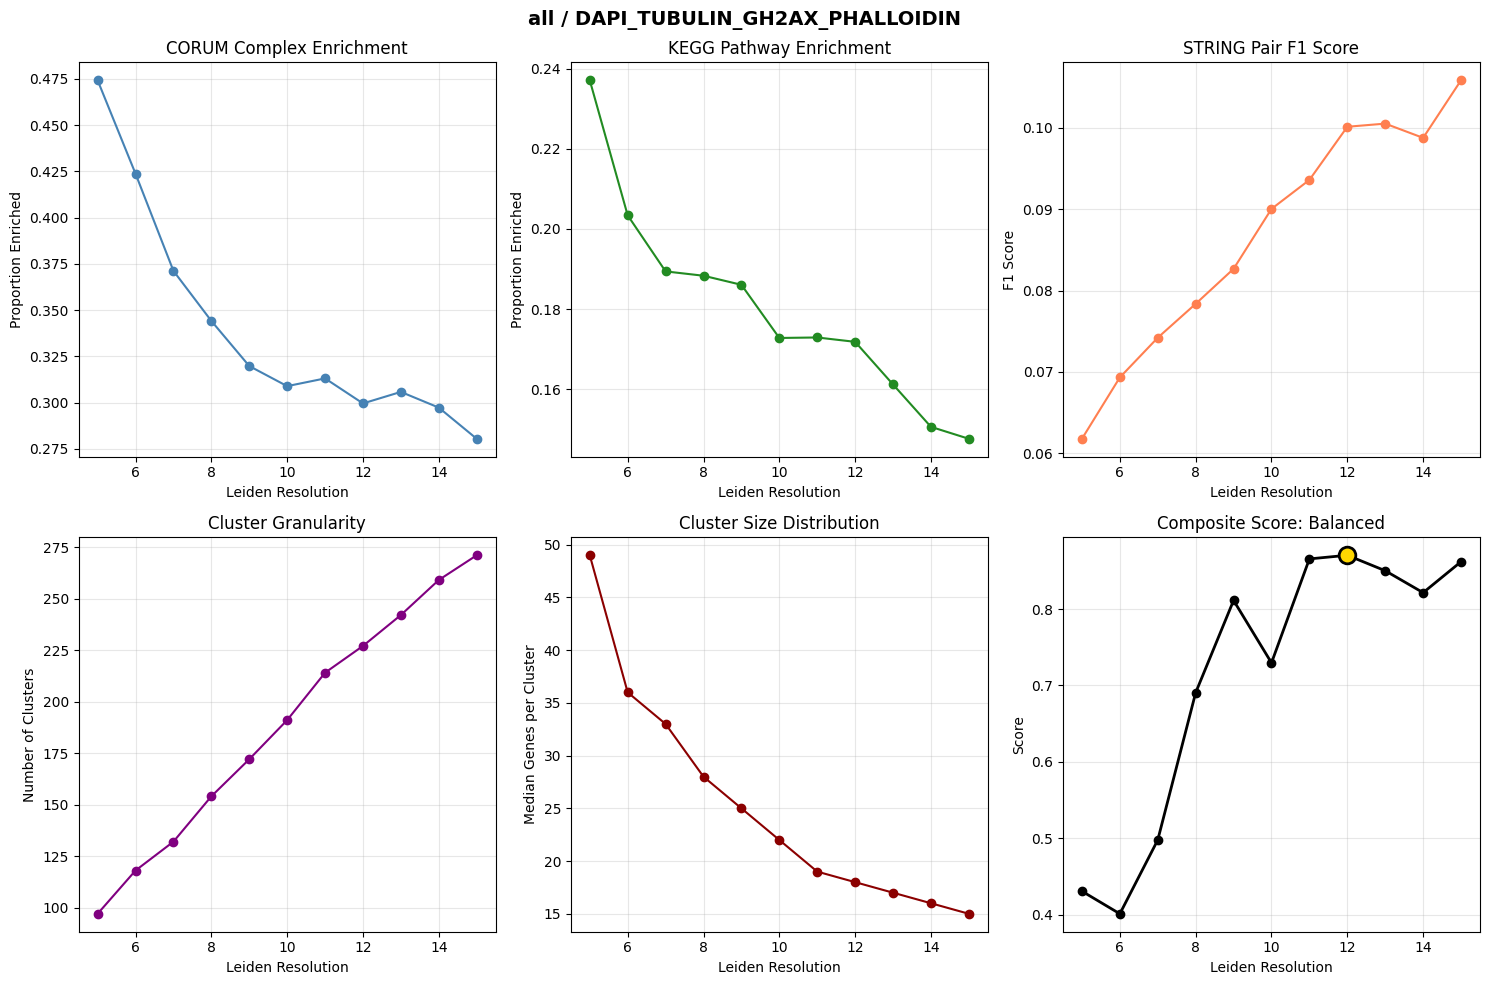


SUMMARY: Optimal Resolutions


,cell_class_channel,resolution,num_clusters,median_size,mean_size,corum_enrich,kegg_enrich,string_f1,balanced_score
0,Interphase_DAPI_TUBULIN_GH2AX_PHALLOIDIN,12,227,18,23.3,33.0%,18.1%,9.8%,0.892
1,Mitotic_DAPI_TUBULIN_GH2AX_PHALLOIDIN,5,222,22,23.8,5.4%,3.2%,6.5%,0.935
2,all_DAPI_TUBULIN_GH2AX_PHALLOIDIN,12,227,18,23.3,30.0%,17.2%,10.0%,0.870


In [7]:
results = analyze_all_resolutions(
    root_fp=ROOT_FP,
    cell_classes=CELL_CLASSES,
    channel_combos=CHANNEL_COMBOS,
    metric=METRIC,
    ideal_size_range=IDEAL_SIZE_RANGE,
    size_metric=SIZE_METRIC,
    show_plots=True,
    top_n_table=10,
    verbose=True,
)

## <font color='red'>SET PARAMETERS</font>

### Cluster Selection for Analysis

Set these parameters to select the specific cluster data to analyze:
- `CHANNEL_COMBO`: Select from available channel combinations
- `CELL_CLASS`: Select from available cell classes
- `LEIDEN_RESOLUTION`: Select from available Leiden resolutions — use the optimal resolution identified above (recommended: **12** for Interphase, **5** for Mitotic)

These parameters determine which folder of cluster data will be analyzed.

In [12]:
CHANNEL_COMBO = "DAPI_TUBULIN_GH2AX_PHALLOIDIN"
CELL_CLASS = "Interphase"
LEIDEN_RESOLUTION = 12

In [13]:
aggregate_file = ROOT_FP / "aggregate" / "tsvs" / f"CeCl-{CELL_CLASS}_ChCo-{CHANNEL_COMBO}__features_genes.tsv"
print(f"Aggregate file: {aggregate_file}")

if not aggregate_file.exists():
    print(f"Aggregate file does not exist: {aggregate_file}")
else:
    print(f"Aggregate file found")

cluster_path = ROOT_FP / "cluster" / CHANNEL_COMBO / CELL_CLASS / str(LEIDEN_RESOLUTION)
print(f"Cluster path: {cluster_path}")

if not cluster_path.exists():
    print(f"Cluster directory does not exist: {cluster_path}")
else:
    print(f"Cluster directory found")

Aggregate file: brieflow_output/aggregate/tsvs/CeCl-Interphase_ChCo-DAPI_TUBULIN_GH2AX_PHALLOIDIN__features_genes.tsv
Aggregate file found
Cluster path: brieflow_output/cluster/DAPI_TUBULIN_GH2AX_PHALLOIDIN/Interphase/12
Cluster directory found


## Feature Plot Analysis

This section generates visualizations to explore the phenotypic effects of gene perturbations in your screen. The plots will help you:

1. **Differential Feature Analysis**: Identify genes with significant phenotypic changes vs. controls
2. **Waterfall Plots**: Rank genes by their effect on specific features of interest
3. **Two-Feature Plots**: Discover relationships between different phenotypic measurements
4. **Heatmaps**: Visualize patterns across multiple features and gene sets simultaneously

The interactive analysis allow you to customize each visualization for your specific biological questions.

In [10]:
cluster_file = cluster_path / "phate_leiden_clustering.tsv"
cluster_df = pd.read_csv(cluster_file, sep="\t")
display(cluster_df)

,gene_symbol_0,cell_count,perturbation_auc,PHATE_0,PHATE_1,cluster,uniprot_entry,uniprot_function,uniprot_link,mean_potential_to_nontargeting,normalized_potential_to_nontargeting
0,UVRAG,9813,0.572157,-0.001815,0.010370,0,Q9P2Y5,Versatile protein that is involved in regulati...,https://www.uniprot.org/uniprotkb/Q9P2Y5/entry,4.351768,0.118080
1,UBXN1,7733,0.582667,-0.001003,0.013264,0,Q04323,Ubiquitin-binding protein that plays a role in...,https://www.uniprot.org/uniprotkb/Q04323/entry,5.384285,0.148160
2,ZP1,7735,0.583338,-0.000889,0.011875,0,P60852,"Component of the zona pellucida, an extracellu...",https://www.uniprot.org/uniprotkb/P60852/entry,5.143185,0.141136
3,LRP5,4970,0.616686,-0.003982,0.007599,0,O75197,Acts as a coreceptor with members of the frizz...,https://www.uniprot.org/uniprotkb/O75197/entry,5.114150,0.140291
4,MRPL48,6035,0.601446,-0.001284,0.012915,0,Q96GC5,NaN,https://www.uniprot.org/uniprotkb/Q96GC5/entry,5.471353,0.150697
...,...,...,...,...,...,...,...,...,...,...,...
5294,GNPNAT1,8938,0.598922,0.007960,-0.001237,225,Q96EK6,NaN,https://www.uniprot.org/uniprotkb/Q96EK6/entry,5.341361,0.146910
5295,CENPX,5545,0.596542,0.010111,0.001290,226,A8MT69,DNA-binding component of the Fanconi anemia (F...,https://www.uniprot.org/uniprotkb/A8MT69/entry,3.600872,0.096205
5296,CSRNP1,6322,0.564617,0.009144,0.007927,226,Q96S65,Binds to the consensus sequence 5'-AGAGTG-3' a...,https://www.uniprot.org/uniprotkb/Q96S65/entry,1.640108,0.039083
5297,H2BC14,3699,0.581338,0.008550,0.008061,226,Q99879,Core component of nucleosome. Nucleosomes wrap...,https://www.uniprot.org/uniprotkb/Q99879/entry,1.493060,0.034799


In [11]:
aggregate_df = pd.read_csv(aggregate_file, sep="\t")
display(aggregate_df)

,gene_symbol_0,cell_count,cell_stage,cell_stage_confidence,nucleus_DAPI_int,nucleus_TUBULIN_int,nucleus_GH2AX_int,nucleus_PHALLOIDIN_int,nucleus_DAPI_mean,nucleus_TUBULIN_mean,...,cytoplasm_zernike_9_1,cytoplasm_zernike_9_3,cytoplasm_zernike_9_5,cytoplasm_zernike_9_7,cytoplasm_zernike_9_9,cytoplasm_number_neighbors_1,cytoplasm_percent_touching_1,cytoplasm_first_neighbor_distance,cytoplasm_second_neighbor_distance,cytoplasm_angle_between_neighbors
0,FBXO2,5604,0.0,-0.024619,-0.000824,0.045683,0.079814,0.035432,-0.051820,-0.003041,...,-0.026569,0.002176,0.000932,-0.003539,0.017854,0.0,-0.042548,0.046708,0.040833,-0.018587
1,PTMA,9231,0.0,-0.287181,-0.007605,-0.090175,-0.024503,-0.096651,0.080466,0.115067,...,-0.084795,-0.003999,0.000284,0.002255,-0.021571,0.0,-0.049332,0.059068,0.079068,-0.041582
2,RELA,6538,0.0,-0.032063,-0.028215,0.010083,0.017447,-0.001332,0.045336,0.107665,...,-0.038160,-0.036138,-0.005769,-0.013125,-0.010944,0.0,-0.037533,0.002843,-0.005916,-0.014255
3,ABCA3,7011,0.0,-0.027690,0.042652,0.038828,0.119421,0.030319,-0.053292,0.015425,...,-0.000380,-0.007679,0.030943,0.010673,0.012243,0.0,0.006565,0.064273,0.076805,-0.025106
4,ALG5,4035,0.0,-0.020956,-0.020131,-0.068353,-0.003300,-0.068886,-0.041163,-0.072902,...,-0.046463,-0.013173,0.034091,-0.005106,-0.010842,0.0,-0.088813,0.035790,0.043934,-0.027615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5294,nontargeting_GCTAGATCTAC,1186,0.0,0.011300,-0.034101,-0.018495,-0.053029,0.055132,0.010481,0.049242,...,-0.046850,-0.066862,0.003989,-0.027159,0.007283,0.0,-0.076401,0.018151,-0.003001,0.001070
5295,nontargeting_TACGTAAGTGA,769,0.0,0.067018,-0.014571,-0.046801,-0.017015,-0.003380,-0.026271,-0.086803,...,0.085490,-0.025006,0.077725,0.106452,0.076461,0.0,0.043045,0.005955,-0.000987,0.068157
5296,nontargeting_ACCCAATGTGG,2434,0.0,-0.000760,0.015730,-0.009826,0.010205,-0.013604,0.061912,-0.038400,...,-0.031072,0.022500,-0.001260,0.030538,0.038039,0.0,0.067236,-0.026296,-0.040882,-0.012989
5297,nontargeting_CGGCTTTGTTG,340,0.0,0.080712,0.108699,0.051580,0.215497,0.018336,0.058243,0.041288,...,0.076942,0.058237,0.105548,0.028433,0.019375,0.0,-0.155802,0.024167,0.105045,-0.040237


## <font color='red'>SET PARAMETERS</font>

### Cluster Selection for Visualization

Set these parameters to select the specific cluster to analyze:
- `CLUSTER_ID`: The cluster of interest to generate plots.

In [ ]:
CLUSTER_ID = None

In [ ]:
print(f"\n{'='*50}")
print(f"Analyzing Cluster {CLUSTER_ID}")
cluster_genes = cluster_df[cluster_df['cluster'] == CLUSTER_ID][config["aggregate"]["perturbation_name_col"]]
print(f"Genes in Cluster {CLUSTER_ID}:" ,", ".join(cluster_genes.unique()))
print(f"{'='*50}")

# Run differential analysis using robust z-score
diff_results = differential_analysis(
    feature_df=aggregate_df,  
    cluster_df=cluster_df,    
    cluster_id=CLUSTER_ID,
    control_type="nontargeting",  
    control_label=config["aggregate"]["control_key"],
    use_nonparametric=True,  
    normalize_method="robust_zscore"
)

# Display results in a more user-friendly format
print("\nTop Upregulated Features:")
up_df = diff_results['top_up'][['feature', 'robust_zscore', 'p_value', 'median_test', 'median_control']]
up_df = up_df.rename(columns={
    'robust_zscore': 'Z-score',
    'p_value': 'p-value',
    'median_test': 'Median (test)',
    'median_control': 'Median (control)'
})
display(up_df.style.format({
    'Z-score': '{:.2f}',
    'p-value': '{:.2e}',
    'Median (test)': '{:.3f}',
    'Median (control)': '{:.3f}'
}))

print("\nTop Downregulated Features:")
down_df = diff_results['top_down'][['feature', 'robust_zscore', 'p_value', 'median_test', 'median_control']]
down_df = down_df.rename(columns={
    'robust_zscore': 'Z-score',
    'p_value': 'p-value',
    'median_test': 'Median (test)',
    'median_control': 'Median (control)'
})
display(down_df.style.format({
    'Z-score': '{:.2f}',
    'p-value': '{:.2e}',
    'Median (test)': '{:.3f}',
    'Median (control)': '{:.3f}'
}))

## <font color='red'>SET PARAMETERS</font>

### Feature Selection for Visualization

Set these parameters to select the specific cluster to analyze:
- `FEATURES_TO_ANALYZE`: The features found in the differential analysis to generate plots for.
- `GENES_TO_LABEL`: The genes within the cluster to label on the plots.

In [ ]:
FEATURES_TO_ANALYZE = None
GENES_TO_LABEL = None

In [ ]:
# Create waterfall plots for selected features
print("\n--- Waterfall Plots for Selected Features ---")
for feature in FEATURES_TO_ANALYZE:
    print(f"\nPlotting: {feature}")
    waterfall_plot(
        feature_df=aggregate_df, 
        feature=feature,
        cluster_df=cluster_df,
        cluster_id=CLUSTER_ID,
        nontargeting_pattern=config["aggregate"]["control_key"],
        title=f"Cluster {CLUSTER_ID}: {feature}",
        label_genes=GENES_TO_LABEL
    )

# Create two-feature plots for combinations
print("\n--- Two-Feature Plots ---")
# Generate all unique pairs of features
feature_pairs = [(FEATURES_TO_ANALYZE[i], FEATURES_TO_ANALYZE[j]) 
                 for i in range(len(FEATURES_TO_ANALYZE)) 
                 for j in range(i+1, len(FEATURES_TO_ANALYZE))]

for feature1, feature2 in feature_pairs:
    print(f"\nPlotting: {feature1} vs {feature2}")
    two_feature_plot(
        feature_df=aggregate_df,
        x=feature1,
        y=feature2,
        cluster_df=cluster_df,
        cluster_id=CLUSTER_ID,
        nontargeting_pattern=config["aggregate"]["control_key"],
        title=f"Cluster {CLUSTER_ID}: {feature1} vs {feature2}",
        label_genes=GENES_TO_LABEL
    )

# Create heatmap with all differential features
print("\n--- Heatmap of Differential Features ---")
# Get top features from differential analysis
top_up = diff_results['top_up']['feature'].tolist() if not diff_results['top_up'].empty else []
top_down = diff_results['top_down']['feature'].tolist() if not diff_results['top_down'].empty else []
diff_features = top_up + top_down

fig, ax, heatmap_data = cluster_heatmap(
    feature_df=aggregate_df,
    cluster_df=cluster_df,
    cluster_ids=[CLUSTER_ID],
    features=diff_features,
    perturbation_name_col=config["aggregate"]["perturbation_name_col"],
    z_score="global",
    title=f"Cluster {CLUSTER_ID}: Top Differential Features",
)

# PHATE plot for the cluster
print("\n--- PHATE Plot for Cluster ---")
phate_fig = plot_phate_leiden_clusters(
    phate_leiden_clustering=cluster_df,
    perturbation_name_col=config["aggregate"]["perturbation_name_col"],
    control_key=config["aggregate"]["control_key"],
    clusters_of_interest=[CLUSTER_ID],
)

## Volcano Plot Analysis

Volcano plots visualize the relationship between effect size (z-score) and statistical significance (-log10 p-value) from bootstrap analysis. This helps identify genes with both large effects and high confidence.

**Prerequisites:** Bootstrap analysis must have been run during the aggregate step.

In [ ]:
# Load bootstrap results
bootstrap_file = ROOT_FP / "aggregate" / "bootstrap" / f"CeCl-{CELL_CLASS}_ChCo-{CHANNEL_COMBO}__all_gene_bootstrap_results.tsv"

if bootstrap_file.exists():
    bootstrap_df = pd.read_csv(bootstrap_file, sep="\t")
    print(f"Loaded bootstrap results: {len(bootstrap_df)} genes")
    
    # Merge bootstrap with feature table
    merged_df = merge_bootstrap_with_genes(
        bootstrap_df=bootstrap_df,
        genes_df=aggregate_df,
        perturbation_name_col=config["aggregate"]["perturbation_name_col"],
        bootstrap_gene_col="gene",
    )
    print(f"Merged data: {len(merged_df)} genes with {len([c for c in merged_df.columns if c.endswith('_fdr')])} features tested")
    display(merged_df.head())
else:
    print(f"Bootstrap file not found: {bootstrap_file}")
    print("Run the aggregate module with bootstrap enabled to generate this data.")
    merged_df = None

## <font color='red'>SET PARAMETERS</font>

### Volcano Plot Configuration

- `VOLCANO_FEATURE`: Feature to plot (must match a bootstrapped feature)
- `VOLCANO_FDR_THRESHOLD`: FDR threshold for significance
- `VOLCANO_ZSCORE_THRESHOLD`: Z-score threshold for effect size

In [ ]:
# Volcano plot parameters
VOLCANO_FEATURE = None  # Set to a feature from differential analysis (e.g., from diff_results)
VOLCANO_FDR_THRESHOLD = 0.05
VOLCANO_ZSCORE_THRESHOLD = 2.0

In [ ]:
if merged_df is not None and VOLCANO_FEATURE is not None:
    # Check if feature has bootstrap data
    log10_col = f"{VOLCANO_FEATURE}_log10"
    if log10_col in merged_df.columns:
        print(f"Creating volcano plot for: {VOLCANO_FEATURE}")
        
        fig, ax = volcano_plot(
            merged_df=merged_df,
            feature=VOLCANO_FEATURE,
            perturbation_name_col=config["aggregate"]["perturbation_name_col"],
            cluster_df=cluster_df,
            cluster_id=CLUSTER_ID,
            fdr_threshold=VOLCANO_FDR_THRESHOLD,
            zscore_threshold=VOLCANO_ZSCORE_THRESHOLD,
            title=f"Cluster {CLUSTER_ID}: {VOLCANO_FEATURE}",
            label_genes=GENES_TO_LABEL,
        )
        plt.show()
        
        # Show summary statistics
        fdr_col = f"{VOLCANO_FEATURE}_fdr"
        if fdr_col in merged_df.columns:
            sig_up = ((merged_df[fdr_col] < VOLCANO_FDR_THRESHOLD) & (merged_df[VOLCANO_FEATURE] >= VOLCANO_ZSCORE_THRESHOLD)).sum()
            sig_down = ((merged_df[fdr_col] < VOLCANO_FDR_THRESHOLD) & (merged_df[VOLCANO_FEATURE] <= -VOLCANO_ZSCORE_THRESHOLD)).sum()
            print(f"\nSignificant genes (FDR < {VOLCANO_FDR_THRESHOLD}, |z| >= {VOLCANO_ZSCORE_THRESHOLD}):")
            print(f"  Upregulated: {sig_up}")
            print(f"  Downregulated: {sig_down}")
    else:
        print(f"Feature '{VOLCANO_FEATURE}' not found in bootstrap results.")
        print(f"Available features: {[c.replace('_log10', '') for c in merged_df.columns if c.endswith('_log10')][:10]}...")
elif merged_df is None:
    print("No bootstrap data available - load bootstrap results first")
else:
    print("Set VOLCANO_FEATURE to create a volcano plot")

## Cell Montage Generation

Generate montages of cells sorted by a specific feature value. This helps visualize the morphological phenotypes associated with perturbations.

**Prerequisites:** Requires phenotype images to be available in the output directory.

## <font color='red'>SET PARAMETERS</font>

### Montage Configuration

- `MONTAGE_FEATURE`: Feature to sort cells by (e.g., from differential analysis above)
- `MONTAGE_GENE`: Gene/perturbation to generate montage for (or None for top perturbations)
- `MONTAGE_NUM_CELLS`: Number of cells to include in montage
- `MONTAGE_ASCENDING`: Sort order (True = lowest values first)

In [ ]:
# Montage parameters
MONTAGE_FEATURE = None  # Set to a feature name from differential analysis
MONTAGE_GENE = None  # Set to a gene symbol, or None for top perturbations by feature
MONTAGE_NUM_CELLS = 30
MONTAGE_CELL_SIZE = 40  # Pixel size of cell bounding box
MONTAGE_SHAPE = (3, 10)  # Grid shape (rows, cols)
MONTAGE_ASCENDING = False  # False = highest values first

In [ ]:
from lib.aggregate.montage_utils import create_cell_montage, add_filenames
from skimage.exposure import rescale_intensity
import numpy as np

if MONTAGE_FEATURE is not None:
    # Load merge data with cell-level info (needed for image paths and coordinates)
    merge_data_path = ROOT_FP / "merge" / "parquet" / f"CeCl-{CELL_CLASS}__merge.parquet"
    
    if merge_data_path.exists():
        merge_data = pd.read_parquet(merge_data_path)
        
        # Add image file paths
        merge_data = add_filenames(merge_data, ROOT_FP)
        
        # Filter to specific gene if provided
        if MONTAGE_GENE is not None:
            cell_data = merge_data[merge_data[config["aggregate"]["perturbation_name_col"]] == MONTAGE_GENE].copy()
            title_suffix = f"Gene: {MONTAGE_GENE}"
        else:
            # Use top perturbations by feature value
            cell_data = merge_data.copy()
            title_suffix = "All perturbations"
        
        if len(cell_data) > 0:
            # Get channel names from config
            channels = config["phenotype"]["channel_names"]
            
            # Create montage sorted by feature
            montages = create_cell_montage(
                cell_data=cell_data,
                channels=channels,
                num_cells=MONTAGE_NUM_CELLS,
                cell_size=MONTAGE_CELL_SIZE,
                shape=MONTAGE_SHAPE,
                selection_params={
                    "method": "sorted",
                    "sort_by": MONTAGE_FEATURE,
                    "ascending": MONTAGE_ASCENDING,
                },
            )
            
            # Display montages for each channel
            fig, axes = plt.subplots(1, len(channels), figsize=(4 * len(channels), 4))
            if len(channels) == 1:
                axes = [axes]
            
            for ax, (channel, montage_array) in zip(axes, montages.items()):
                # Normalize for display
                montage_display = rescale_intensity(montage_array, in_range="image", out_range=(0, 1))
                ax.imshow(montage_display, cmap="gray")
                ax.set_title(channel)
                ax.axis("off")
            
            sort_order = "ascending" if MONTAGE_ASCENDING else "descending"
            plt.suptitle(f"Montage sorted by {MONTAGE_FEATURE} ({sort_order})\n{title_suffix}", fontsize=12)
            plt.tight_layout()
            plt.show()
        else:
            print(f"No cells found for gene: {MONTAGE_GENE}")
    else:
        print(f"Merge data not found: {merge_data_path}")
else:
    print("Set MONTAGE_FEATURE to generate a montage")

## Mozzarellm: LLM-based Gene Cluster Analysis

### Overview
[Mozzarellm](https://github.com/cheeseman-lab/mozzarellm) is a Python package that leverages Large Language Models (LLMs) to analyze gene clusters for pathway identification and novel gene discovery.

### Prerequisites

Install mozzarellm in your Brieflow environment:

```bash
pip install git+https://github.com/cheeseman-lab/mozzarellm.git
```

Set up API keys in a `.env` file in the analysis directory:

```bash
# .env file
ANTHROPIC_API_KEY=your_key_here
# or OPENAI_API_KEY=your_key_here
# or GOOGLE_API_KEY=your_key_here
```

### Workflow

1. **Configure** mozzarellm parameters below and write to `config.yml`
2. **Run** the analysis script: `bash 13.run_mozzarellm.sh`

The script supports resume (automatically skips completed clusters) and saves results incrementally.

## <font color='red'>SET PARAMETERS</font>

### Mozzarellm Configuration

Configure which clustering result to analyze with mozzarellm:

- `MOZZARELLM_CELL_CLASS`: Cell class to analyze
- `MOZZARELLM_CHANNEL_COMBO`: Channel combination
- `MOZZARELLM_RESOLUTION`: Leiden resolution (choose your optimal resolution)
- `MOZZARELLM_MODEL`: LLM model to use
- `MOZZARELLM_SCREEN_CONTEXT`: Context about your screen for the LLM

In [ ]:
# Mozzarellm configuration - set these based on your analysis above
MOZZARELLM_CELL_CLASS = CELL_CLASS  # Use the same as selected above, or override
MOZZARELLM_CHANNEL_COMBO = CHANNEL_COMBO  # Use the same as selected above, or override
MOZZARELLM_RESOLUTION = LEIDEN_RESOLUTION  # Use the same as selected above, or override

# Model selection
MOZZARELLM_MODEL = "claude-opus-4-6"  # or "gpt-4o", "gemini-2.0-flash", etc.
MOZZARELLM_TEMPERATURE = 0.0

# Screen context - customize this for your specific screen
MOZZARELLM_SCREEN_CONTEXT = """
These clusters are from an optical pooled screen (OPS) that measured morphological
phenotypes in human cells. The screen involved perturbing genes using CRISPR knockout
and imaging the resulting cellular morphology via fluorescence microscopy using a
cell-painting-derived panel, specifically DAPI, Tubulin, γH2AX, and Phalloidin. Genes grouped 
within a cluster tend to exhibit similar phenotypes, suggesting they may participate in the same 
biological process or pathway.
"""

In [ ]:
# Verify the clustering file exists
mozzarellm_cluster_path = ROOT_FP / "cluster" / MOZZARELLM_CHANNEL_COMBO / MOZZARELLM_CELL_CLASS / str(MOZZARELLM_RESOLUTION)
mozzarellm_cluster_file = mozzarellm_cluster_path / "phate_leiden_clustering.tsv"

print(f"Mozzarellm will analyze: {mozzarellm_cluster_file}")
if mozzarellm_cluster_file.exists():
    cluster_preview = pd.read_csv(mozzarellm_cluster_file, sep="\t")
    print(f"File exists: {len(cluster_preview)} genes, {cluster_preview['cluster'].nunique()} clusters")
else:
    print(f"File not found - make sure clustering has been run")

## Write Mozzarellm Configuration to config.yml

Run this cell to save the mozzarellm configuration. The shell script `13.run_mozzarellm.sh` will read these parameters.

In [ ]:
# Add mozzarellm section to config
config["mozzarellm"] = {
    "cell_class": MOZZARELLM_CELL_CLASS,
    "channel_combo": MOZZARELLM_CHANNEL_COMBO,
    "leiden_resolution": MOZZARELLM_RESOLUTION,
    "model": MOZZARELLM_MODEL,
    "temperature": MOZZARELLM_TEMPERATURE,
    "screen_context": MOZZARELLM_SCREEN_CONTEXT.strip(),
}

# Write updated config
from lib.shared.configuration_utils import CONFIG_FILE_HEADER

with open(CONFIG_FILE_PATH, "w") as config_file:
    config_file.write(CONFIG_FILE_HEADER)
    yaml.dump(config, config_file, default_flow_style=False, sort_keys=False)

print("Mozzarellm configuration written to config.yml")
print(f"\nConfiguration:")
print(f"  Cell class: {MOZZARELLM_CELL_CLASS}")
print(f"  Channel combo: {MOZZARELLM_CHANNEL_COMBO}")
print(f"  Resolution: {MOZZARELLM_RESOLUTION}")
print(f"  Model: {MOZZARELLM_MODEL}")

## Run Mozzarellm Analysis

Now run the analysis from the terminal:

```bash
cd analysis/
bash 13.run_mozzarellm.sh
```

The script will:
1. Read configuration from `config.yml`
2. Load the clustering results
3. Analyze each cluster with the LLM (with progress bar)
4. Save results incrementally (can resume if interrupted)

**Output location:** `{cluster_path}/mozzarellm/`
- `clusters/` - Individual cluster results (JSON, for resume)
- `{model}_results.json` - Combined analysis with all clusters
- `{model}_summaries.tsv` - One row per cluster (pathway, confidence, counts)
- `{model}_flagged_genes.tsv` - One row per flagged gene (priority, rationale)